# Практична робота 4.8. Регресія та класифікація з використанням TensorFlow
**Виконав:** Жвавий Ігор · **номер за журналом:** N = 1

| Параметр | Як визначено в умові | Значення |
|---|---|---|
| Обсяг даних для регресії | 1000 × N | **1000** |
| Обсяг даних для класифікації | 1000 × N | **1000** |
| Кількість класів | N + 2 | **3** |

**Мета:** освоїти генерацію даних для задач регресії та класифікації, побудувати нейронні мережі засобами TensorFlow/Keras, навчити їх та оцінити якість.

**Особливість варіанта:** вибірка мала (1000 об'єктів), тому головна ризикована точка тут перенавчання. Для протидії йому використано L2-регуляризацію, Dropout і ранню зупинку, а окремим експериментом перевірено, як розмір прихованого шару впливає на якість.

## 1. Бібліотеки та параметри варіанта

In [1]:
# %pip install tensorflow scikit-learn matplotlib seaborn pandas   # якщо бібліотеки не встановлені
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

N = 1                         # номер за журналом
N_SAMPLES = 1000 * N          # 1000
N_CLASSES = N + 2             # 3
SEED = 1
keras.utils.set_random_seed(SEED)
sns.set_theme(style="ticks")
plt.rcParams["figure.dpi"] = 80
%config InlineBackend.figure_formats = ["jpeg"]
print("TensorFlow", tf.__version__, "| N =", N, "| об'єктів:", N_SAMPLES, "| класів:", N_CLASSES)

I0000 00:00:1791385159.954178   18539 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791385162.004168   18539 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.21.0 | N = 1 | об'єктів: 1000 | класів: 3


## 2. Генерація та візуалізація даних
### 2.1. Регресія
`make_regression`: 1000 об'єктів, 5 ознак (4 інформативні), шум 15. Чисто лінійну залежність добре описує і звичайна лінійна регресія, тому до цільової змінної я додав дві нелінійні складові: **взаємодію ознак** `x0·x2` та **модуль** `|x3|`. Так видно, що саме дає нейронна мережа.

In [2]:
X_reg, y_base = make_regression(n_samples=N_SAMPLES, n_features=5, n_informative=4, noise=15, random_state=SEED)
y_reg = y_base + 35 * X_reg[:, 0] * X_reg[:, 2] + 45 * np.abs(X_reg[:, 3])
reg_df = pd.DataFrame(X_reg, columns=[f"x{i}" for i in range(5)]).assign(y=y_reg)
reg_df.describe().round(2)

,x0,x1,x2,x3,x4,y
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,0.02,0.04,-0.01,-0.00,0.07,36.21
std,1.02,0.99,0.96,1.02,1.02,90.98
min,-3.05,-3.25,-2.48,-3.02,-3.15,-242.87
25%,-0.65,-0.64,-0.69,-0.67,-0.62,-24.39
50%,0.03,0.04,-0.02,-0.02,0.11,29.84
75%,0.70,0.68,0.62,0.68,0.75,89.07
max,3.32,2.89,3.96,3.03,3.43,396.14


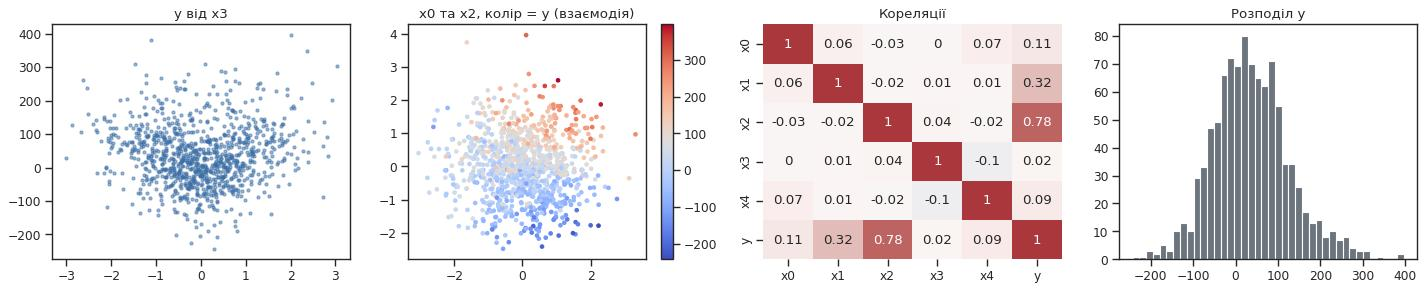

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
axes[0].scatter(reg_df.x3, reg_df.y, s=8, alpha=0.5, color="#3a6ea5"); axes[0].set_title("y від x3")
sc = axes[1].scatter(reg_df.x0, reg_df.x2, c=reg_df.y, s=10, cmap="coolwarm"); axes[1].set_title("x0 та x2, колір = y (взаємодія)")
plt.colorbar(sc, ax=axes[1])
sns.heatmap(reg_df.corr().round(2), annot=True, cmap="vlag", center=0, cbar=False, ax=axes[2]); axes[2].set_title("Кореляції")
axes[3].hist(reg_df.y, bins=40, color="#6c757d"); axes[3].set_title("Розподіл y")
plt.tight_layout(); plt.show()

Кореляція `y` з `x3` слабка, хоча `x3` суттєво впливає на ціль: кореляція «бачить» лише лінійний зв'язок, а V-подібну форму пропускає. Взаємодія `x0·x2` взагалі не помітна на жодній окремій ознаці.

### 2.2. Класифікація
`make_classification`: 1000 об'єктів, **3 класи**, 10 ознак (6 інформативних, 2 надлишкові, 2 шумові), по 2 кластери на клас, `class_sep=0.9`. Класи частково перекриваються.

Об'єктів у класах: [331 328 341]


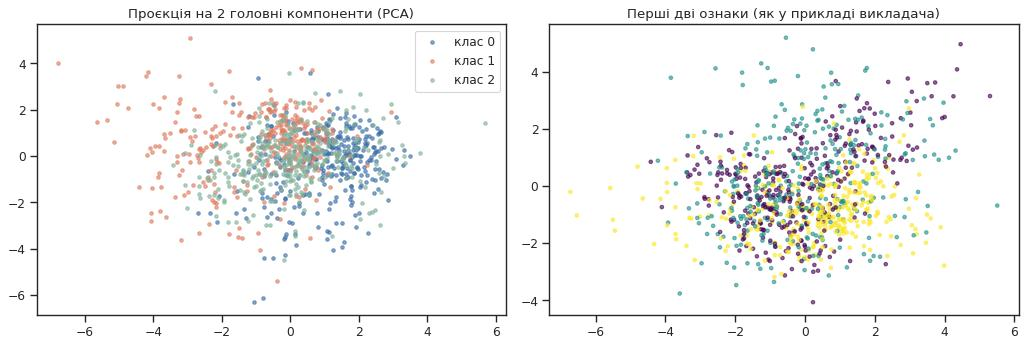

In [4]:
X_clf, y_clf = make_classification(n_samples=N_SAMPLES, n_features=10, n_informative=6, n_redundant=2,
                                   n_classes=N_CLASSES, n_clusters_per_class=2, class_sep=0.9,
                                   flip_y=0.02, random_state=SEED)
print("Об'єктів у класах:", np.bincount(y_clf))
Z = PCA(2, random_state=SEED).fit_transform(StandardScaler().fit_transform(X_clf))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for k, col in zip(range(N_CLASSES), ["#3a6ea5", "#e07a5f", "#81b29a"]):
    axes[0].scatter(Z[y_clf == k, 0], Z[y_clf == k, 1], s=10, alpha=0.6, color=col, label=f"клас {k}")
axes[0].legend(); axes[0].set_title("Проєкція на 2 головні компоненти (PCA)")
axes[1].scatter(X_clf[:, 0], X_clf[:, 1], c=y_clf, cmap="viridis", s=10, alpha=0.6); axes[1].set_title("Перші дві ознаки (як у прикладі викладача)")
plt.tight_layout(); plt.show()

## 3. Регресія
### 3.1. Розподіл даних
Train 70 %, validation 15 %, test 15 %. Масштабування ознак і цільової змінної виконую за параметрами, обчисленими тільки на train.

In [5]:
Xa, Xr_te, ya, yr_te = train_test_split(X_reg, y_reg, test_size=0.15, random_state=SEED)
Xr_tr, Xr_va, yr_tr, yr_va = train_test_split(Xa, ya, test_size=0.15 / 0.85, random_state=SEED)
sx = StandardScaler().fit(Xr_tr); sy = StandardScaler().fit(yr_tr.reshape(-1, 1))
f = lambda a: sy.transform(a.reshape(-1, 1)).ravel()
Xr_tr_s, Xr_va_s, Xr_te_s = sx.transform(Xr_tr), sx.transform(Xr_va), sx.transform(Xr_te)
print("train / val / test:", len(Xr_tr), len(Xr_va), len(Xr_te))

train / val / test: 700 150 150


### 3.2. Модель
Модель побудована через **Functional API** Keras: `5 → Dense(32, ReLU) → Dense(16, ReLU) → Dense(1)`. До ваг прихованих шарів додано L2-регуляризацію (штраф 1e-4 за великі ваги), бо даних мало. Функція втрат MSE, оптимізатор Adam, batch 32, рання зупинка з терпінням 25 епох.

In [6]:
def build_reg():
    inp = keras.Input(shape=(5,), name="features")
    h = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(inp)
    h = layers.Dense(16, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(h)
    out = layers.Dense(1, name="y_hat")(h)
    m = keras.Model(inp, out, name="reg_net")
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=0.003), loss="mse")
    return m
reg_net = build_reg(); reg_net.summary()
stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
h_reg = reg_net.fit(Xr_tr_s, f(yr_tr), validation_data=(Xr_va_s, f(yr_va)), epochs=500, batch_size=32, callbacks=[stop], verbose=0)
print("Зупинка на епосі", len(h_reg.history["loss"]), "| найкраща епоха", int(np.argmin(h_reg.history["val_loss"])) + 1)

Model: "reg_net"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_hat (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Зупинка на епосі 91 | найкраща епоха 66


### 3.3. Оцінка: MSE на тестовій вибірці і порівняння з лінійною регресією

In [7]:
pred_nn = sy.inverse_transform(reg_net.predict(Xr_te_s, verbose=0)).ravel()
pred_lr = LinearRegression().fit(Xr_tr_s, yr_tr).predict(Xr_te_s)
reg_tab = pd.DataFrame({name: {"MSE": mean_squared_error(yr_te, p), "MAE": mean_absolute_error(yr_te, p), "R²": r2_score(yr_te, p)}
                        for name, p in [("Лінійна регресія", pred_lr), ("Нейронна мережа", pred_nn)]}).T
print(f"Дисперсія закладеного шуму: {15**2} (нижня межа MSE)")
reg_tab.round(3)

Дисперсія закладеного шуму: 225 (нижня межа MSE)


,MSE,MAE,R²
Лінійна регресія,1707.353,31.209,0.737
Нейронна мережа,331.418,15.010,0.949


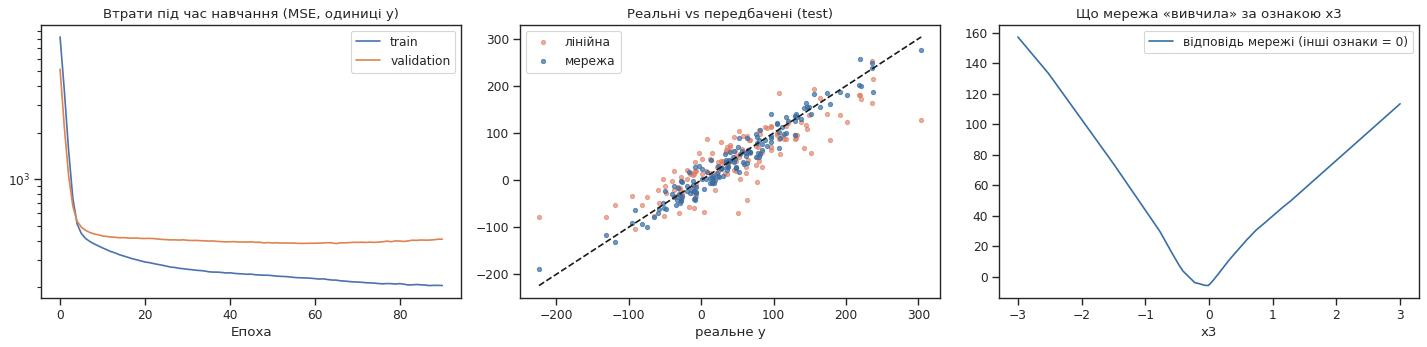

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
s2 = sy.scale_[0] ** 2
axes[0].plot(np.array(h_reg.history["loss"]) * s2, label="train"); axes[0].plot(np.array(h_reg.history["val_loss"]) * s2, label="validation")
axes[0].set_yscale("log"); axes[0].set_title("Втрати під час навчання (MSE, одиниці y)"); axes[0].set_xlabel("Епоха"); axes[0].legend()
lim = [yr_te.min(), yr_te.max()]
axes[1].scatter(yr_te, pred_lr, s=14, alpha=0.6, color="#e07a5f", label="лінійна"); axes[1].scatter(yr_te, pred_nn, s=14, alpha=0.7, color="#3a6ea5", label="мережа")
axes[1].plot(lim, lim, "k--"); axes[1].set_title("Реальні vs передбачені (test)"); axes[1].set_xlabel("реальне y"); axes[1].legend()
grid = np.linspace(-3, 3, 200); probe = np.zeros((200, 5)); probe[:, 3] = grid
resp = sy.inverse_transform(reg_net.predict(sx.transform(probe), verbose=0)).ravel()
axes[2].plot(grid, resp, color="#3a6ea5", label="відповідь мережі (інші ознаки = 0)")
axes[2].set_title("Що мережа «вивчила» за ознакою x3"); axes[2].set_xlabel("x3"); axes[2].legend()
plt.tight_layout(); plt.show()

## 4. Класифікація
### 4.1. Розподіл даних (зі стратифікацією за класом)

In [9]:
Xa, Xc_te, ya, yc_te = train_test_split(X_clf, y_clf, test_size=0.15, stratify=y_clf, random_state=SEED)
Xc_tr, Xc_va, yc_tr, yc_va = train_test_split(Xa, ya, test_size=0.15 / 0.85, stratify=ya, random_state=SEED)
sc = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_va_s, Xc_te_s = sc.transform(Xc_tr), sc.transform(Xc_va), sc.transform(Xc_te)
print("train / val / test:", len(Xc_tr), len(Xc_va), len(Xc_te))

train / val / test: 700 150 150


### 4.2. Модель
`10 → Dense(32, ReLU) → Dropout(0.2) → Dense(16, ReLU) → Dense(3, Softmax)`. Вихідний шар має 3 нейрони за кількістю класів, softmax повертає ймовірності. Функція втрат `sparse_categorical_crossentropy`, бо мітки є цілими числами 0, 1, 2.

In [10]:
def build_clf(hidden=32, seed=SEED):
    keras.utils.set_random_seed(seed)
    m = keras.Sequential([keras.Input(shape=(10,)),
                          layers.Dense(hidden, activation="relu"), layers.Dropout(0.2),
                          layers.Dense(max(hidden // 2, 4), activation="relu"),
                          layers.Dense(N_CLASSES, activation="softmax")], name=f"clf_net_{hidden}")
    m.compile(optimizer=keras.optimizers.Adam(0.003), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m
clf_net = build_clf(); clf_net.summary()
stop_c = keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)
h_clf = clf_net.fit(Xc_tr_s, yc_tr, validation_data=(Xc_va_s, yc_va), epochs=500, batch_size=32, callbacks=[stop_c], verbose=0)
print("Зупинка на епосі", len(h_clf.history["loss"]), "| найкраща епоха", int(np.argmin(h_clf.history["val_loss"])) + 1)

Model: "clf_net_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 931 (3.64 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

Зупинка на епосі 94 | найкраща епоха 69


### 4.3. Оцінка: accuracy, матриця плутанини, порівняння з логістичною регресією та KNN

In [11]:
p_nn = clf_net.predict(Xc_te_s, verbose=0).argmax(1)
p_lr = LogisticRegression(max_iter=2000).fit(Xc_tr_s, yc_tr).predict(Xc_te_s)
p_knn = KNeighborsClassifier(n_neighbors=15).fit(Xc_tr_s, yc_tr).predict(Xc_te_s)
clf_tab = pd.DataFrame({"Accuracy (test)": [accuracy_score(yc_te, p) for p in (p_lr, p_knn, p_nn)]},
                       index=["Логістична регресія", "KNN (k=15)", "Нейронна мережа"]).round(3)
print(f"Випадкове вгадування: {1 / N_CLASSES:.3f}")
clf_tab

Випадкове вгадування: 0.333


,Accuracy (test)
Логістична регресія,0.787
KNN (k=15),0.820
Нейронна мережа,0.900


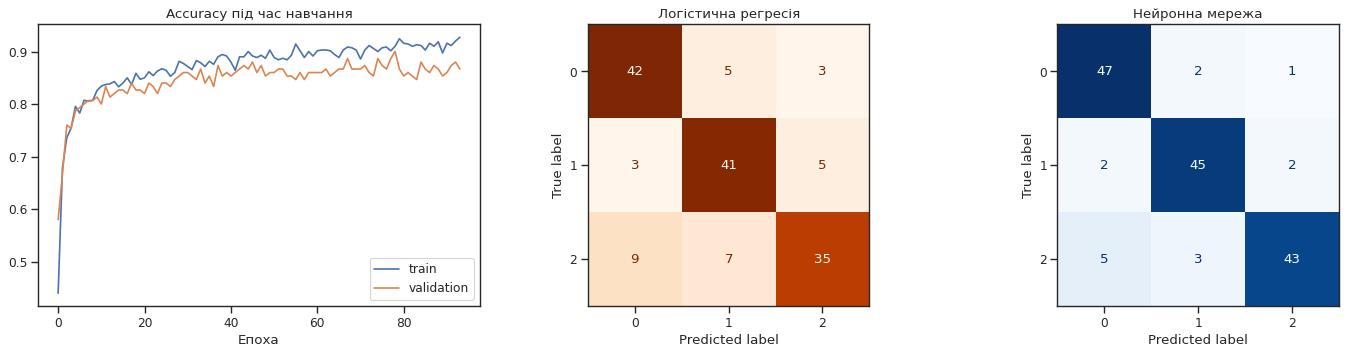

              precision    recall  f1-score   support

           0      0.870     0.940     0.904        50
           1      0.900     0.918     0.909        49
           2      0.935     0.843     0.887        51

    accuracy                          0.900       150
   macro avg      0.902     0.901     0.900       150
weighted avg      0.902     0.900     0.900       150



In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
axes[0].plot(h_clf.history["accuracy"], label="train"); axes[0].plot(h_clf.history["val_accuracy"], label="validation")
axes[0].set_title("Accuracy під час навчання"); axes[0].set_xlabel("Епоха"); axes[0].legend()
ConfusionMatrixDisplay(confusion_matrix(yc_te, p_lr)).plot(ax=axes[1], cmap="Oranges", colorbar=False); axes[1].set_title("Логістична регресія")
ConfusionMatrixDisplay(confusion_matrix(yc_te, p_nn)).plot(ax=axes[2], cmap="Blues", colorbar=False); axes[2].set_title("Нейронна мережа")
plt.tight_layout(); plt.show()
print(classification_report(yc_te, p_nn, digits=3))

### 4.4. Експеримент: скільки нейронів потрібно у прихованому шарі
Для малої вибірки важливо не зробити мережу завеликою. Навчаю ту саму архітектуру з різною шириною першого прихованого шару (3 запуски з різним seed для кожного варіанта) і дивлюся на accuracy на validation.

In [13]:
rows = []
for hidden in [4, 8, 16, 32, 64, 128]:
    for s in range(3):
        m = build_clf(hidden, seed=100 + s)
        hh = m.fit(Xc_tr_s, yc_tr, validation_data=(Xc_va_s, yc_va), epochs=500, batch_size=32, verbose=0,
                   callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=25, restore_best_weights=True)])
        rows.append({"нейронів": hidden, "параметрів": m.count_params(),
                     "train acc": m.evaluate(Xc_tr_s, yc_tr, verbose=0)[1], "val acc": m.evaluate(Xc_va_s, yc_va, verbose=0)[1]})
exp = pd.DataFrame(rows).groupby("нейронів").agg({"параметрів": "first", "train acc": "mean", "val acc": ["mean", "std"]}).round(3)
exp

параметрів train acc val acc       
              first      mean    mean    std
нейронів                                    
4                79     0.782   0.740  0.031
8               139     0.838   0.798  0.030
16              339     0.890   0.827  0.029
32              931     0.919   0.862  0.010
64             2883     0.948   0.862  0.017
128            9859     0.937   0.871  0.008

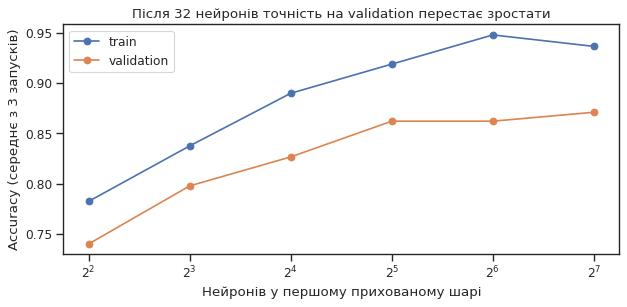

In [14]:
e = pd.DataFrame(rows).groupby("нейронів").mean()
plt.figure(figsize=(8, 4))
plt.plot(e.index, e["train acc"], marker="o", label="train"); plt.plot(e.index, e["val acc"], marker="o", label="validation")
plt.xscale("log", base=2); plt.xlabel("Нейронів у першому прихованому шарі"); plt.ylabel("Accuracy (середнє з 3 запусків)")
plt.title("Після 32 нейронів точність на validation перестає зростати"); plt.legend(); plt.tight_layout(); plt.show()

## 5. Висновки

**Дані.** Згідно з варіантом N = 1 згенеровано по 1000 об'єктів для регресії та класифікації, у задачі класифікації 3 класи. Класи збалансовані (близько 333 об'єктів у кожному), тому accuracy є коректною метрикою.

**Регресія.** Нейронна мережа `5 → 32 → 16 → 1` (737 параметрів) отримала на тестовій вибірці **MSE ≈ 331** (MAE ≈ 15, R² ≈ 0.95). Лінійна регресія на тих самих даних має MSE ≈ 1707 (R² ≈ 0.74), тобто помилка мережі приблизно в 5 разів менша. Лінійна модель не може відтворити взаємодію `x0·x2` і V-подібну залежність від `|x3|`, а мережа їх вивчила, що видно з графіка відповіді за ознакою `x3`. Нижня межа MSE визначається закладеним шумом (15² = 225), тому результат мережі вже близький до максимально можливого.

**Класифікація.** Мережа `10 → 32 → Dropout(0.2) → 16 → 3` (931 параметр) досягла **accuracy 0.90** на тесті. Логістична регресія дає 0.787, KNN 0.82, випадкове вгадування 0.333. Кожен клас складається з двох кластерів, тож межі між класами нелінійні, і лінійна модель їх не розділяє. Матриця плутанини має чітку діагональ, precision і recall усіх класів лежать у межах 0.84–0.94; найчастіше помилки стосуються класу 2 (recall 0.84).

**Мала вибірка та перенавчання.** Рання зупинка спрацювала на 91-й епосі для регресії та на 94-й для класифікації (найкращі ваги з 66-ї та 69-ї епох відновлено). Експеримент із шириною прихованого шару показав, що точність на validation зростає від 0.74 (4 нейрони) до 0.86 (32 нейрони) і далі практично не змінюється, а точність на train продовжує рости. Тому для 1000 об'єктів обрано 32 нейрони: більша мережа не дає приросту, лише додає параметри й ризик перенавчання.

**Загальний висновок.** Нейронні мережі суттєво перевершили лінійні моделі в обох задачах, оскільки дані містять нелінійні залежності. На малій вибірці якість мережі визначає не стільки її розмір, скільки правильний розподіл даних і контроль перенавчання (validation, рання зупинка, L2 і Dropout).